In [33]:
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import torchvision.transforms as T
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchsummary import summary   # pip install torchsummary
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [ ]:
!pip install torch torchvision matplotlib numpy Pillow torchsummary

In [34]:
# ─────────────────────────────────────────────
#  Oxford-IIIT Pet Dataset
#  Masks: 1 = foreground (pet), 2 = background, 3 = border/unknown
#  We remap → foreground=1, everything else=0  (binary segmentation)
# ─────────────────────────────────────────────

class OxfordPetDataset(Dataset):
    """
    Oxford-IIIT Pet Dataset for binary semantic segmentation.

    Directory structure expected:
        root/
          images/   *.jpg
          annotations/
            trimaps/ *.png   (pixel values: 1=pet, 2=background, 3=border)

    Args:
        root      (str)  : Path to dataset root folder.
        split     (str)  : 'train', 'val', or 'test'.
        img_size  (int)  : Images are resized to (img_size x img_size).
        augment   (bool) : Apply random augmentations (train split only).
        download  (bool) : Download the dataset via torchvision if not present.
    """

    def __init__(
        self,
        root: str,
        split: str = "train",
        img_size: int = 256,
        augment: bool = True,
        download: bool = True,
    ):
        super().__init__()
        assert split in ("train", "val", "test"), "split must be train / val / test"

        self.root = root
        self.split = split
        self.img_size = img_size
        self.augment = augment and (split == "train")

        # ── Download via torchvision (handles the tar extraction too) ──────────
        if download:
            import torchvision.datasets as tvd
            tvd.OxfordIIITPet(
                root=root,
                split="trainval",
                target_types="segmentation",
                download=True,
            )
            tvd.OxfordIIITPet(
                root=root,
                split="test",
                target_types="segmentation",
                download=True,
            )

        # ── Collect (image_path, mask_path) pairs ─────────────────────────────
        # torchvision stores them under root/oxford-iiit-pet/
        pet_root = os.path.join(root, "oxford-iiit-pet")
        img_dir  = os.path.join(pet_root, "images")
        mask_dir = os.path.join(pet_root, "annotations", "trimaps")

        # Build list from the official split files
        if split in ("train", "val"):
            list_file = os.path.join(pet_root, "annotations", "trainval.txt")
        else:
            list_file = os.path.join(pet_root, "annotations", "test.txt")

        with open(list_file) as f:
            lines = [l.strip().split()[0] for l in f if l.strip()]

        # For train/val split the official trainval list 90/10
        if split in ("train", "val"):
            rng = random.Random(42)
            rng.shuffle(lines)
            cut = int(0.9 * len(lines))
            lines = lines[:cut] if split == "train" else lines[cut:]

        self.samples = [
            (
                os.path.join(img_dir,  name + ".jpg"),
                os.path.join(mask_dir, name + ".png"),
            )
            for name in lines
        ]

    # ── helpers ───────────────────────────────────────────────────────────────

    def _remap_mask(self, mask: Image.Image) -> torch.Tensor:
        """
        Trimap values: 1=pet foreground, 2=background, 3=ambiguous border.
        Remap to binary: foreground (pet) → 1, everything else → 0.
        """
        mask_np = np.array(mask, dtype=np.int64)
        binary  = (mask_np == 1).astype(np.int64)          # 1 where pet, 0 elsewhere
        return torch.from_numpy(binary)                     # shape [H, W]

    def _apply_transforms(
        self, img: Image.Image, mask: Image.Image
    ):
        """Resize, optional augmentations, then to-tensor + normalise."""

        # 1. Resize both image and mask to img_size × img_size
        img  = TF.resize(img,  [self.img_size, self.img_size],
                         interpolation=T.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=T.InterpolationMode.NEAREST)   # ← no blending for masks

        # 2. Random augmentations (applied identically to image AND mask)
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)

            # Random vertical flip
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)

            # Random rotation ±15°
            angle = random.uniform(-15, 15)
            img  = TF.rotate(img,  angle)
            mask = TF.rotate(mask, angle)

            # Color jitter — image only (not mask)
            jitter = T.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.05)
            img = jitter(img)

        # 3. Image → tensor [3, H, W] and normalise with ImageNet stats
        img_tensor = TF.to_tensor(img)                     # [0, 1]
        img_tensor = TF.normalize(
            img_tensor,
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225],
        )

        # 4. Mask → binary long tensor [H, W]
        mask_tensor = self._remap_mask(mask)

        return img_tensor, mask_tensor

    # ── Dataset interface ─────────────────────────────────────────────────────

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, mask_path = self.samples[idx]

        img  = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)                       # stays as palette/L mode

        img_tensor, mask_tensor = self._apply_transforms(img, mask)
        return img_tensor, mask_tensor


# ─────────────────────────────────────────────
#  DataLoader factory
# ─────────────────────────────────────────────

def get_dataloaders(
    root: str       = "./data",
    img_size: int   = 256,
    batch_size: int = 8,
    num_workers: int = 2,
    download: bool  = True,
):
    """
    Returns three DataLoaders: train, val, test.

    Usage:
        train_loader, val_loader, test_loader = get_dataloaders()
    """
    train_ds = OxfordPetDataset(root, split="train", img_size=img_size,
                                augment=True,  download=download)
    val_ds   = OxfordPetDataset(root, split="val",   img_size=img_size,
                                augment=False, download=download)
    test_ds  = OxfordPetDataset(root, split="test",  img_size=img_size,
                                augment=False, download=download)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"Dataset sizes  →  train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
    print(f"Batch size: {batch_size}  |  Image size: {img_size}×{img_size}")

    return train_loader, val_loader, test_loader




Dataset sizes  →  train: 3312 | val: 368 | test: 3669
Batch size: 4  |  Image size: 256×256
Image batch shape : torch.Size([4, 3, 256, 256])
Mask batch shape  : torch.Size([4, 256, 256])
Unique mask values: tensor([0, 1])


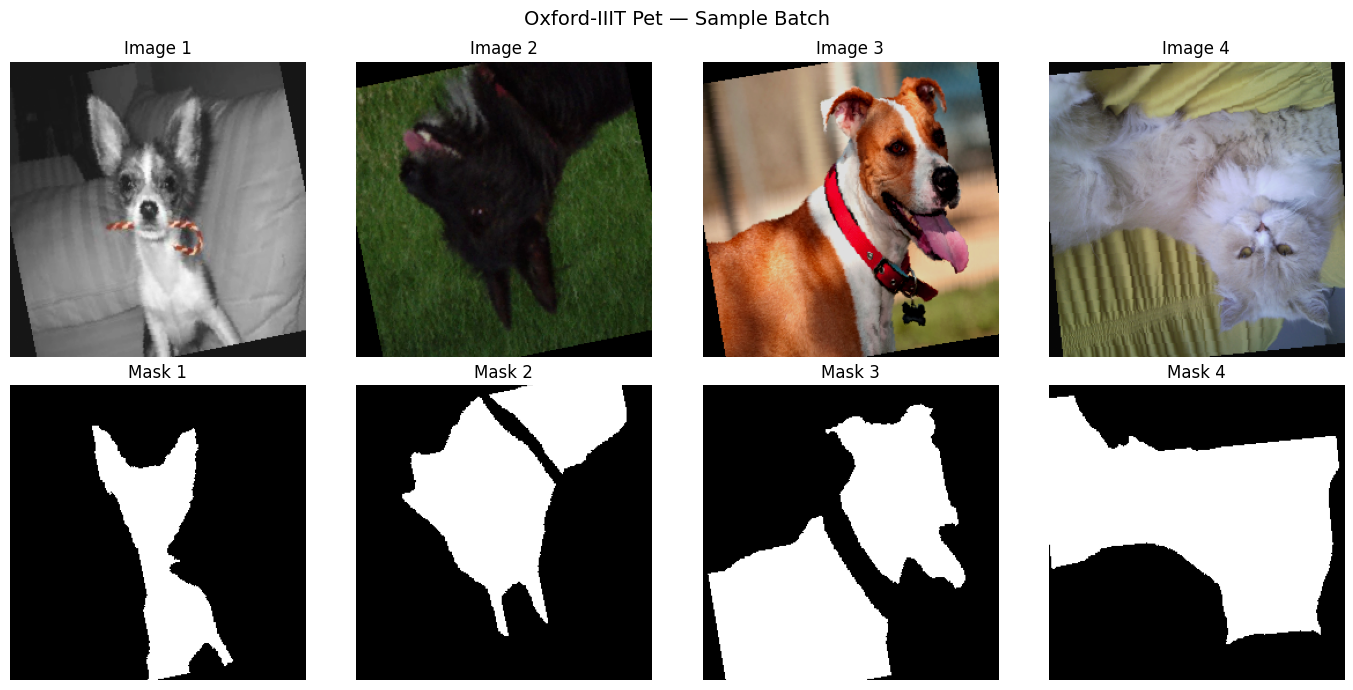

Saved visualisation to sample_batch.png


In [35]:
# ─────────────────────────────────────────────
#  Quick sanity check  (run: python dataset.py)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

train_loader, val_loader, test_loader = get_dataloaders(
    root="./data", img_size=256, batch_size=4, download=True
)

imgs, masks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")    # [B, 3, 256, 256]
print(f"Mask batch shape  : {masks.shape}")   # [B, 256, 256]
print(f"Unique mask values: {masks.unique()}")# tensor([0, 1])

# Visualise first 4 samples
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(4):
    img_vis = imgs[i] * std + mean           # de-normalise for display
    img_vis = img_vis.permute(1, 2, 0).clamp(0, 1).numpy()

    axes[0, i].imshow(img_vis)
    axes[0, i].set_title(f"Image {i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(masks[i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Mask {i+1}")
    axes[1, i].axis("off")

plt.suptitle("Oxford-IIIT Pet — Sample Batch", fontsize=14)
plt.tight_layout()
plt.savefig("sample_batch.png", dpi=120)
plt.show()
print("Saved visualisation to sample_batch.png")

In [36]:

# ─────────────────────────────────────────────
#  Building Block: Double Convolution
#  Conv3x3 → BN → ReLU → Conv3x3 → BN → ReLU
# ─────────────────────────────────────────────

class DoubleConv(nn.Module):
    """
    Two consecutive:  Conv(3×3) → BatchNorm → ReLU
    Used in every encoder block, bottleneck, and decoder block.

    Args:
        in_channels  : number of input feature maps
        out_channels : number of output feature maps
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            # First conv
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Second conv
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [37]:
class DoubleConv(nn.Module):
    """
    Two consecutive:  Conv(3×3) → BatchNorm → ReLU
    Used in every encoder block, bottleneck, and decoder block.

    Args:
        in_channels  : number of input feature maps
        out_channels : number of output feature maps
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.block = nn.Sequential(
            # First conv
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            # Second conv
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)



In [38]:
# ─────────────────────────────────────────────
#  Encoder Block
#  DoubleConv  →  save skip  →  MaxPool2×2
# ─────────────────────────────────────────────

class EncoderBlock(nn.Module):
    """
    One step of the contracting (encoder) path.
    Returns BOTH the skip-connection feature map AND the downsampled output.

    Args:
        in_channels  : input channels
        out_channels : output channels
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)       # full-resolution features  → saved for skip connection
        down = self.pool(skip)    # downsampled (H/2, W/2)    → passed to next encoder
        return skip, down


In [39]:
# ─────────────────────────────────────────────
#  Decoder Block
#  Upsample  →  Concat skip  →  DoubleConv
# ─────────────────────────────────────────────

class DecoderBlock(nn.Module):
    """
    One step of the expansive (decoder) path.
    Upsamples the input, concatenates the skip connection, then applies DoubleConv.

    Args:
        in_channels  : channels coming INTO this block (from previous decoder step)
        out_channels : channels after DoubleConv
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        # Upsample by 2× using transposed convolution (learnable upsampling)
        self.upsample = nn.ConvTranspose2d(
            in_channels, out_channels,
            kernel_size=2, stride=2
        )

        # After concatenating skip (out_channels) + upsampled (out_channels)
        # → input to DoubleConv is out_channels * 2
        self.conv = DoubleConv(out_channels * 2, out_channels)

    def forward(self, x, skip):
        x = self.upsample(x)                  # (B, C, H, W) → (B, C/2, 2H, 2W)

        # Handle odd dimensions: if skip and x differ by 1 pixel, pad x
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

        x = torch.cat([skip, x], dim=1)       # concat along channel axis → (B, C, H, W)
        x = self.conv(x)
        return x



In [40]:
# ─────────────────────────────────────────────
#  Full U-Net
# ─────────────────────────────────────────────

class UNet(nn.Module):
    """
    Simplified U-Net for binary semantic segmentation.

    Architecture:
        Encoder:     3 → 64 → 128 → 256
        Bottleneck:  256 → 512
        Decoder:     512 → 256 → 128 → 64
        Output:      64  → num_classes  (1×1 conv)

    Args:
        in_channels  : number of input image channels (3 for RGB)
        num_classes  : 1 for binary segmentation (sigmoid output)
        features     : list of channel sizes for each encoder level
    """

    def __init__(
        self,
        in_channels: int  = 3,
        num_classes: int  = 1,
        features: list    = [64, 128, 256, 512],
    ):
        super().__init__()

        # ── Encoder ───────────────────────────────────────────────────────────
        self.encoders = nn.ModuleList()
        current_channels = in_channels
        for feat in features[:-1]:                    # [64, 128, 256]
            self.encoders.append(EncoderBlock(current_channels, feat))
            current_channels = feat

        # ── Bottleneck ────────────────────────────────────────────────────────
        # Deepest layer — no pooling, just DoubleConv
        self.bottleneck = DoubleConv(features[-2], features[-1])   # 256 → 512

        # ── Decoder ───────────────────────────────────────────────────────────
        self.decoders = nn.ModuleList()
        reversed_features = list(reversed(features))               # [512, 256, 128, 64]
        for i in range(len(reversed_features) - 1):
            self.decoders.append(
                DecoderBlock(reversed_features[i], reversed_features[i + 1])
            )

        # ── Output head ───────────────────────────────────────────────────────
        # 1×1 conv to map final feature maps to class scores
        self.output_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        # ── Encoder forward pass ──────────────────────────────────────────────
        skips = []
        for encoder in self.encoders:
            skip, x = encoder(x)
            skips.append(skip)                        # save skip connections

        # ── Bottleneck ────────────────────────────────────────────────────────
        x = self.bottleneck(x)

        # ── Decoder forward pass ──────────────────────────────────────────────
        skips = list(reversed(skips))                 # match decoder order (deepest first)
        for i, decoder in enumerate(self.decoders):
            x = decoder(x, skips[i])

        # ── Output ────────────────────────────────────────────────────────────
        x = self.output_conv(x)
        return torch.sigmoid(x)


In [41]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

model = UNet(in_channels=3, num_classes=1).to(device)

# Test with a dummy batch — same shape as our DataLoader output
dummy_input = torch.randn(4, 3, 256, 256).to(device)
output = model(dummy_input)

print(f"Input  shape : {dummy_input.shape}")   # [4, 3, 256, 256]
print(f"Output shape : {output.shape}")        # [4, 1, 256, 256]
assert output.shape == (4, 1, 256, 256), "Shape mismatch!"
print("\n✅ U-Net forward pass successful!\n")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable:,}")


Using device: cuda

Input  shape : torch.Size([4, 3, 256, 256])
Output shape : torch.Size([4, 1, 256, 256])

✅ U-Net forward pass successful!

Total parameters     : 7,700,161
Trainable parameters : 7,700,161


In [42]:
# ─────────────────────────────────────────────
#  Loss Functions
# ─────────────────────────────────────────────

class DiceLoss(nn.Module):
    """
    Dice Loss for binary segmentation.
    Dice = 2 * |X ∩ Y| / (|X| + |Y|)
    DiceLoss = 1 - Dice

    Works directly on probabilities (after sigmoid).
    Smooth=1 prevents division by zero.
    """
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs   = logits
        targets = targets.float()

        # Flatten spatial dimensions
        probs   = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


In [43]:
class CombinedLoss(nn.Module):
    """
    BCE Loss + Dice Loss combined.
    BCE handles per-pixel accuracy.
    Dice handles class imbalance (background >> foreground pixels).

    Args:
        bce_weight  : weight for BCE component  (default 0.5)
        dice_weight : weight for Dice component (default 0.5)
    """
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.bce  = nn.BCELoss()  # applies sigmoid internally — numerically stable
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        targets = targets.float()
        # BCEWithLogitsLoss expects targets same shape as logits → add channel dim
        bce_loss  = self.bce(logits.squeeze(1), targets)
        dice_loss = self.dice(logits.squeeze(1), targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss



In [44]:
# ─────────────────────────────────────────────
#  Metrics
# ─────────────────────────────────────────────

def pixel_accuracy(logits, targets):
    """Percentage of correctly classified pixels."""
    preds   = (logits.squeeze(1) > 0.5).long()
    correct = (preds == targets).sum().item()
    total   = targets.numel()
    return correct / total


def iou_score(logits, targets, smooth: float = 1e-6):
    """
    Intersection over Union (Jaccard Index) for binary segmentation.
    IoU = |X ∩ Y| / |X ∪ Y|
    """
    preds   = (logits.squeeze(1) > 0.5).long()
    targets = targets.long()

    intersection = (preds & targets).sum().item()
    union        = (preds | targets).sum().item()
    return (intersection + smooth) / (union + smooth)

def mean_iou(preds, targets, num_classes=2, smooth=1e-6):
    """
    Computes IoU per class AND averaged (mean IoU).
    Returns both individual class IoUs and the mean.
    """
    preds   = (preds.squeeze(1) > 0.5).long()    # [B, H, W]
    targets = targets.long()                       # [B, H, W]

    iou_per_class = []
    for cls in range(num_classes):
        pred_cls   = (preds == cls)
        target_cls = (targets == cls)

        intersection = (pred_cls & target_cls).sum().item()
        union        = (pred_cls | target_cls).sum().item()

        iou = (intersection + smooth) / (union + smooth)
        iou_per_class.append(iou)

    miou = sum(iou_per_class) / len(iou_per_class)

    return {
        "iou_background": iou_per_class[0],   # Class 0
        "iou_foreground": iou_per_class[1],   # Class 1
        "miou":           miou,               # mean
    }


def dice_score(preds, targets, smooth=1e-6):
    """
    Dice Coefficient as an evaluation metric (not loss).
    Dice = 2 * |X ∩ Y| / (|X| + |Y|)
    """
    preds   = (preds.squeeze(1) > 0.5).float()
    targets = targets.float()

    preds   = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum().item()
    dice = (2.0 * intersection + smooth) / (preds.sum().item() + targets.sum().item() + smooth)
    return dice

# ─────────────────────────────────────────────
#  Single Epoch — Train
# ─────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Runs one full pass over the training set.
    Returns average loss, pixel accuracy, and IoU for the epoch.
    """
    model.train()

    total_loss = 0.0
    total_acc  = 0.0
    total_miou = {"iou_background": 0.0, "iou_foreground": 0.0, "miou": 0.0}
    total_dice = 0.0

    for batch_idx, (images, masks) in enumerate(loader):
        images = images.to(device)
        masks  = masks.to(device)

        # ── Forward pass ──────────────────────────────────────────────────────
        logits = model(images)                     # [B, 1, H, W]  raw logits

        # ── Compute loss ──────────────────────────────────────────────────────
        loss = criterion(logits, masks)

        # ── Backward pass ─────────────────────────────────────────────────────
        optimizer.zero_grad()                      # clear old gradients
        loss.backward()                            # compute new gradients
        optimizer.step()                           # update weights

        # ── Track metrics ─────────────────────────────────────────────────────
        total_loss += loss.item()
        total_acc  += pixel_accuracy(logits.detach(), masks)

        batch_miou = mean_iou(logits.detach(), masks)
        total_miou["iou_background"] += batch_miou["iou_background"]
        total_miou["iou_foreground"] += batch_miou["iou_foreground"]
        total_miou["miou"]           += batch_miou["miou"]

        total_dice += dice_score(logits.detach(), masks)

        # Print progress every 20 batches
        if (batch_idx + 1) % 20 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}]  loss: {loss.item():.4f}")

    n = len(loader)
    avg_miou = {k: v/n for k, v in total_miou.items()}
    return total_loss/n, total_acc/n, avg_miou, total_dice/n


In [45]:
# ─────────────────────────────────────────────
#  Single Epoch — Validation
# ─────────────────────────────────────────────

def validate(model, loader, criterion, device):
    """
    Runs one full pass over the validation set (no gradient updates).
    Returns average loss, pixel accuracy, and IoU.
    """

    model.eval()

    total_loss = 0.0
    total_acc  = 0.0
    total_miou = {"iou_background": 0.0, "iou_foreground": 0.0, "miou": 0.0}
    total_dice = 0.0

    with torch.no_grad():                        # disable gradient tracking → saves memory
        for images, masks in loader:
            images = images.to(device)
            masks  = masks.to(device)

            preds = model(images)
            loss  = criterion(preds, masks)

            total_loss += loss.item()
            total_acc  += pixel_accuracy(preds, masks)

            batch_miou = mean_iou(preds, masks)
            total_miou["iou_background"] += batch_miou["iou_background"]
            total_miou["iou_foreground"] += batch_miou["iou_foreground"]
            total_miou["miou"]           += batch_miou["miou"]

            total_dice += dice_score(preds, masks)

    n = len(loader)
    avg_miou = {k: v/n for k, v in total_miou.items()}
    return total_loss/n, total_acc/n, avg_miou, total_dice/n



In [46]:
# ─────────────────────────────────────────────
#  Full Training Loop
# ─────────────────────────────────────────────

def train(
    model,
    train_loader,
    val_loader,
    num_epochs:   int   = 25,
    lr:           float = 1e-4,
    device:       str   = None,
    save_path:    str   = "best_model.pth",
):
    """
    Full training loop with:
      - Combined BCE + Dice loss
      - Adam optimizer
      - ReduceLROnPlateau scheduler
      - Best model checkpointing
      - Loss / accuracy / IoU curves

    Args:
        model        : UNet instance
        train_loader : training DataLoader
        val_loader   : validation DataLoader
        num_epochs   : number of training epochs
        lr           : initial learning rate
        device       : 'cuda' or 'cpu' (auto-detected if None)
        save_path    : where to save the best model weights

    Returns:
        history dict with train/val loss, accuracy, IoU per epoch
    """

    # ── Setup ─────────────────────────────────────────────────────────────────
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    # ── History tracking ──────────────────────────────────────────────────────
    history = {
        "train_loss":   [], "val_loss":   [],
        "train_acc":    [], "val_acc":    [],
        "train_iou_bg": [], "val_iou_bg": [],   # Class 0 background
        "train_iou_fg": [], "val_iou_fg": [],   # Class 1 foreground
        "train_miou":   [], "val_miou":   [],   # mean IoU
        "train_dice":   [], "val_dice":   [],
    }

    best_val_loss = float("inf")

    print(f"Training on : {device}")
    print(f"Epochs      : {num_epochs}")
    print(f"LR          : {lr}")
    print("─" * 65)

    # ── Epoch loop ────────────────────────────────────────────────────────────
    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch [{epoch}/{num_epochs}]")

        # Train
        train_loss, train_acc, train_miou, train_dice= train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        # Validate
        val_loss, val_acc, val_miou,   val_dice = validate(
            model, val_loader, criterion, device
        )

        # Scheduler step (reduce LR if val_loss stops improving)
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
            print(f"  💾 Best model saved  (val_loss: {val_loss:.4f})")

        # Record history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_iou_bg"].append(train_miou["iou_background"])
        history["train_iou_fg"].append(train_miou["iou_foreground"])
        history["train_miou"].append(train_miou["miou"])
        history["val_iou_bg"].append(val_miou["iou_background"])
        history["val_iou_fg"].append(val_miou["iou_foreground"])
        history["val_miou"].append(val_miou["miou"])
        history["train_dice"].append(train_dice)
        history["val_dice"].append(val_dice)

        # Print epoch summary
        print(f"  Train → loss: {train_loss:.4f} | acc: {train_acc:.4f} | "
              f"IoU_bg: {train_miou['iou_background']:.4f} | "
              f"IoU_fg: {train_miou['iou_foreground']:.4f} | "
              f"mIoU: {train_miou['miou']:.4f} | Dice: {train_dice:.4f}")

        print(f"  Val   → loss: {val_loss:.4f} | acc: {val_acc:.4f} | "
              f"IoU_bg: {val_miou['iou_background']:.4f} | "
              f"IoU_fg: {val_miou['iou_foreground']:.4f} | "
              f"mIoU: {val_miou['miou']:.4f} | Dice: {val_dice:.4f}")
        print("─" * 65)

    print(f"\n✅ Training complete! Best val loss: {best_val_loss:.4f}")
    print(f"   Best model saved to: {save_path}")

    return history


In [47]:
def plot_history(history: dict, save_path: str = "training_curves.png"):

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0,0].plot(epochs, history["train_loss"], label="Train Loss", color="royalblue")
    axes[0,0].plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
    axes[0,0].set_title("Loss")
    axes[0,0].set_xlabel("Epoch")
    axes[0,0].legend()
    axes[0,0].grid(True)

    # Pixel Accuracy
    axes[0,1].plot(epochs, history["train_acc"], label="Train Acc", color="royalblue")
    axes[0,1].plot(epochs, history["val_acc"],   label="Val Acc",   color="tomato")
    axes[0,1].set_title("Pixel Accuracy")
    axes[0,1].set_xlabel("Epoch")
    axes[0,1].legend()
    axes[0,1].grid(True)

    # IoU — per class + mean
    axes[1,0].plot(epochs, history["train_iou_bg"], label="Train IoU bg", color="royalblue",  linestyle="dashed")
    axes[1,0].plot(epochs, history["train_iou_fg"], label="Train IoU fg", color="royalblue")
    axes[1,0].plot(epochs, history["train_miou"],   label="Train mIoU",   color="royalblue",  linestyle="dotted")
    axes[1,0].plot(epochs, history["val_iou_bg"],   label="Val IoU bg",   color="tomato",     linestyle="dashed")
    axes[1,0].plot(epochs, history["val_iou_fg"],   label="Val IoU fg",   color="tomato")
    axes[1,0].plot(epochs, history["val_miou"],     label="Val mIoU",     color="tomato",     linestyle="dotted")
    axes[1,0].set_title("IoU per Class + Mean IoU")
    axes[1,0].set_xlabel("Epoch")
    axes[1,0].legend(fontsize=8)
    axes[1,0].grid(True)

    # Dice
    axes[1,1].plot(epochs, history["train_dice"], label="Train Dice", color="royalblue")
    axes[1,1].plot(epochs, history["val_dice"],   label="Val Dice",   color="tomato")
    axes[1,1].set_title("Dice Coefficient")
    axes[1,1].set_xlabel("Epoch")
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.suptitle("U-Net Training Curves", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"Saved training curves to {save_path}")

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=3, num_classes=1).to(device)

history = train(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    num_epochs   = 25,
    lr           = 1e-3,
    device       = device,
    save_path    = "best_model.pth",
)

Training on : cuda
Epochs      : 25
LR          : 0.001
─────────────────────────────────────────────────────────────────

Epoch [1/25]
  Batch [20/828]  loss: 0.6331
  Batch [40/828]  loss: 0.5519
  Batch [60/828]  loss: 0.6762
  Batch [80/828]  loss: 0.5659
  Batch [100/828]  loss: 0.6547
  Batch [120/828]  loss: 0.6409
  Batch [140/828]  loss: 0.6538
  Batch [160/828]  loss: 0.6468
  Batch [180/828]  loss: 0.6676
  Batch [200/828]  loss: 0.5716
  Batch [220/828]  loss: 0.6078
  Batch [240/828]  loss: 0.6165
  Batch [260/828]  loss: 0.5231
  Batch [280/828]  loss: 0.5473
  Batch [300/828]  loss: 0.6258
  Batch [320/828]  loss: 0.6294
  Batch [340/828]  loss: 0.6608
  Batch [360/828]  loss: 0.5396
  Batch [380/828]  loss: 0.6481
  Batch [400/828]  loss: 0.5426
  Batch [420/828]  loss: 0.6045
  Batch [440/828]  loss: 0.5979
  Batch [460/828]  loss: 0.5286
  Batch [480/828]  loss: 0.5325
  Batch [500/828]  loss: 0.5962
  Batch [520/828]  loss: 0.4910
  Batch [540/828]  loss: 0.5071
  Ba

In [51]:
from evaluate import (
    load_best_model,
    evaluate_model,
    print_results,
    visualize_predictions,
    plot_history
)

In [53]:
import evaluate
evaluate.pixel_accuracy = pixel_accuracy
evaluate.mean_iou       = mean_iou
evaluate.dice_score     = dice_score

✅ Model loaded from: best_model.pth
   Running on: cuda

═════════════════════════════════════════════
       EVALUATION RESULTS — TEST SET
═════════════════════════════════════════════
  Pixel Accuracy       : 0.9111  (91.11%)
  IoU — Background     : 0.8756
  IoU — Foreground     : 0.7460
  Mean IoU (mIoU)      : 0.8108
  Dice Coefficient     : 0.8509
═════════════════════════════════════════════


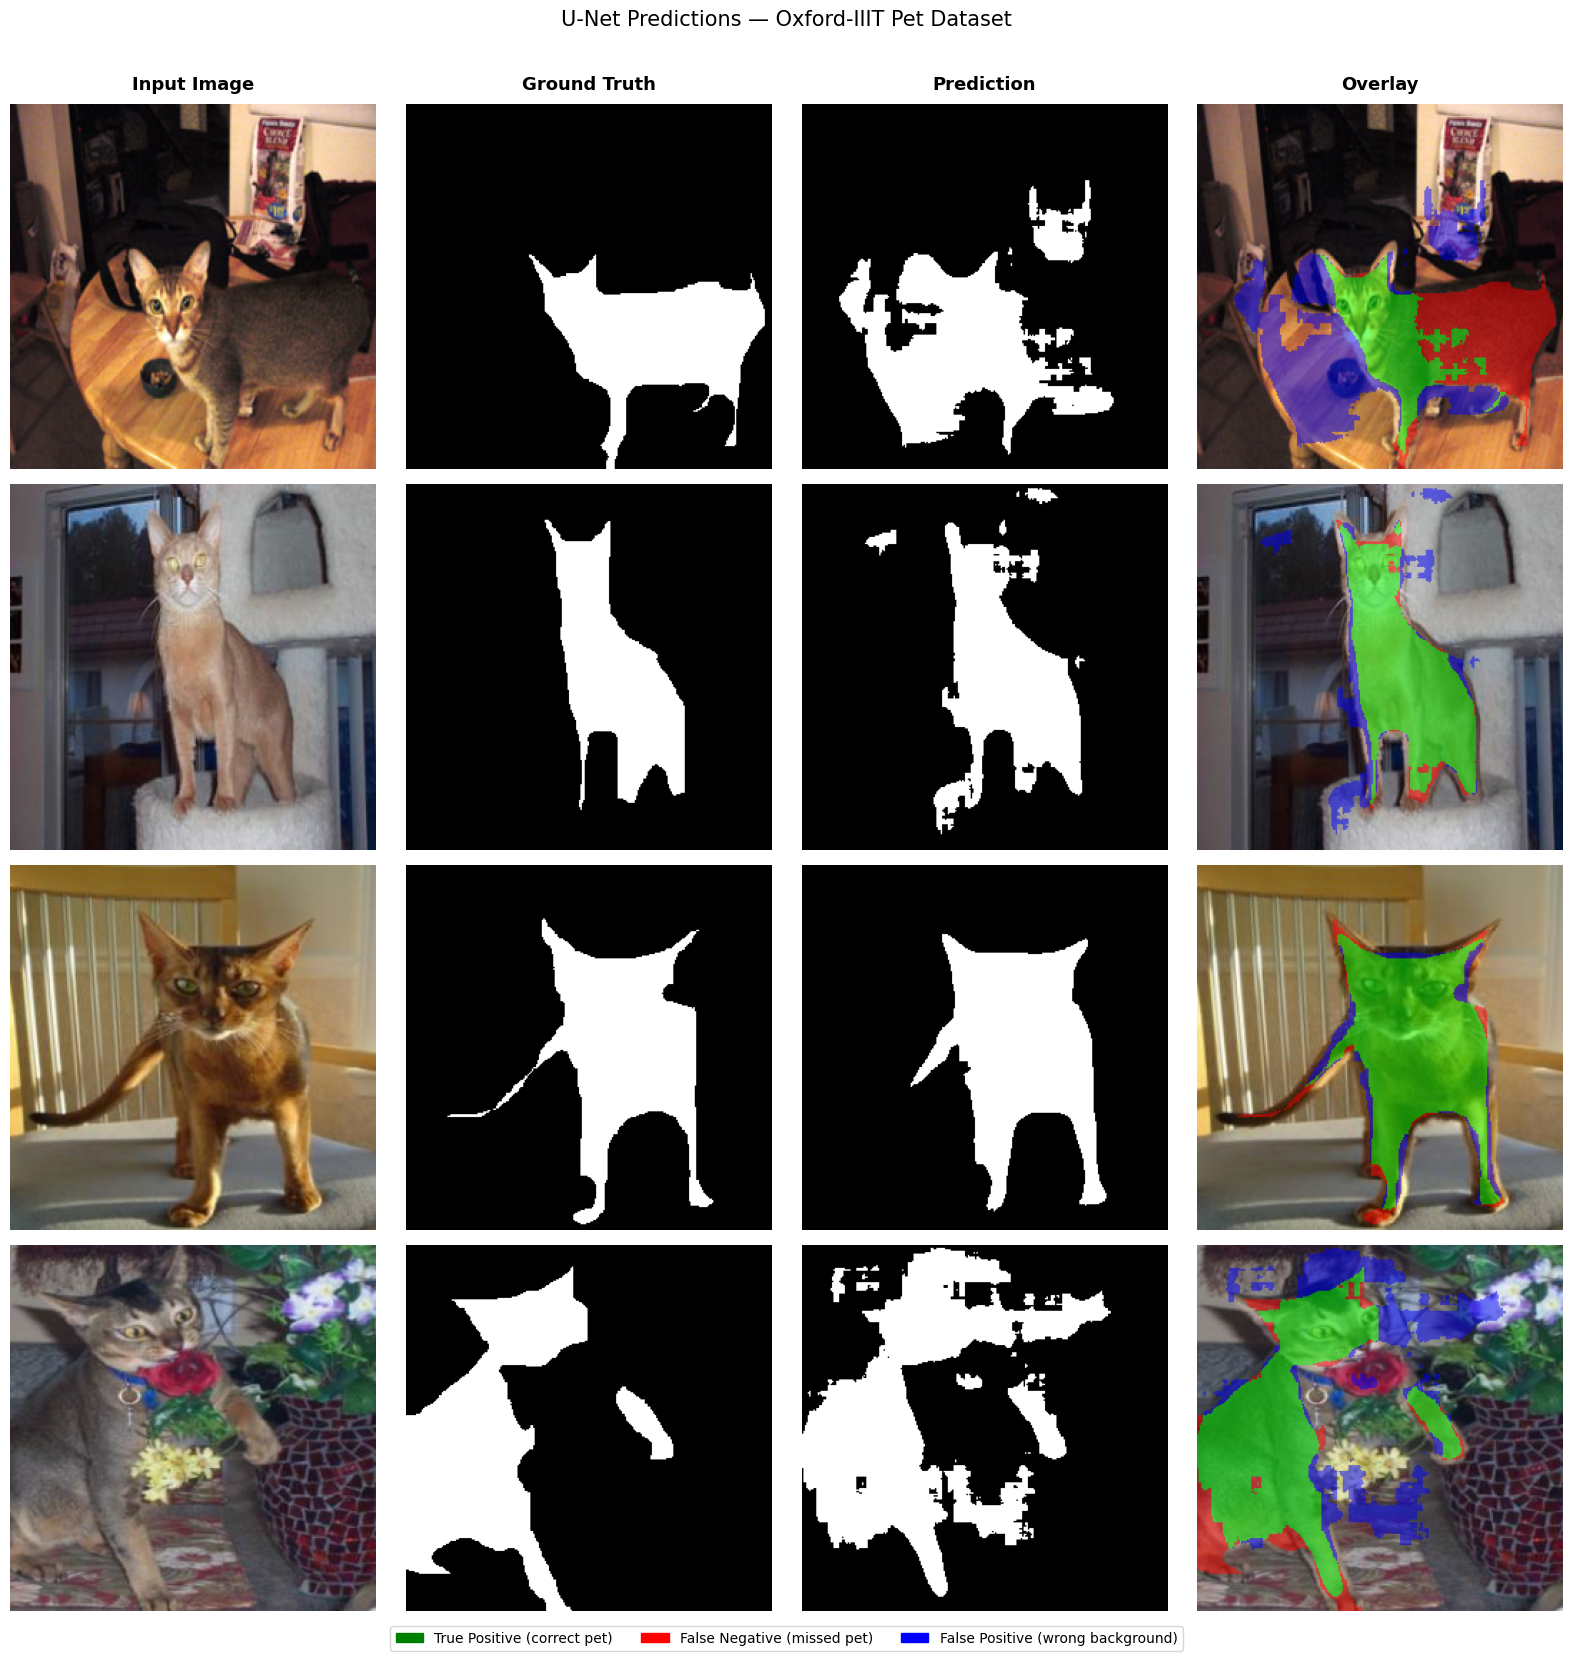

Saved predictions to predictions.png


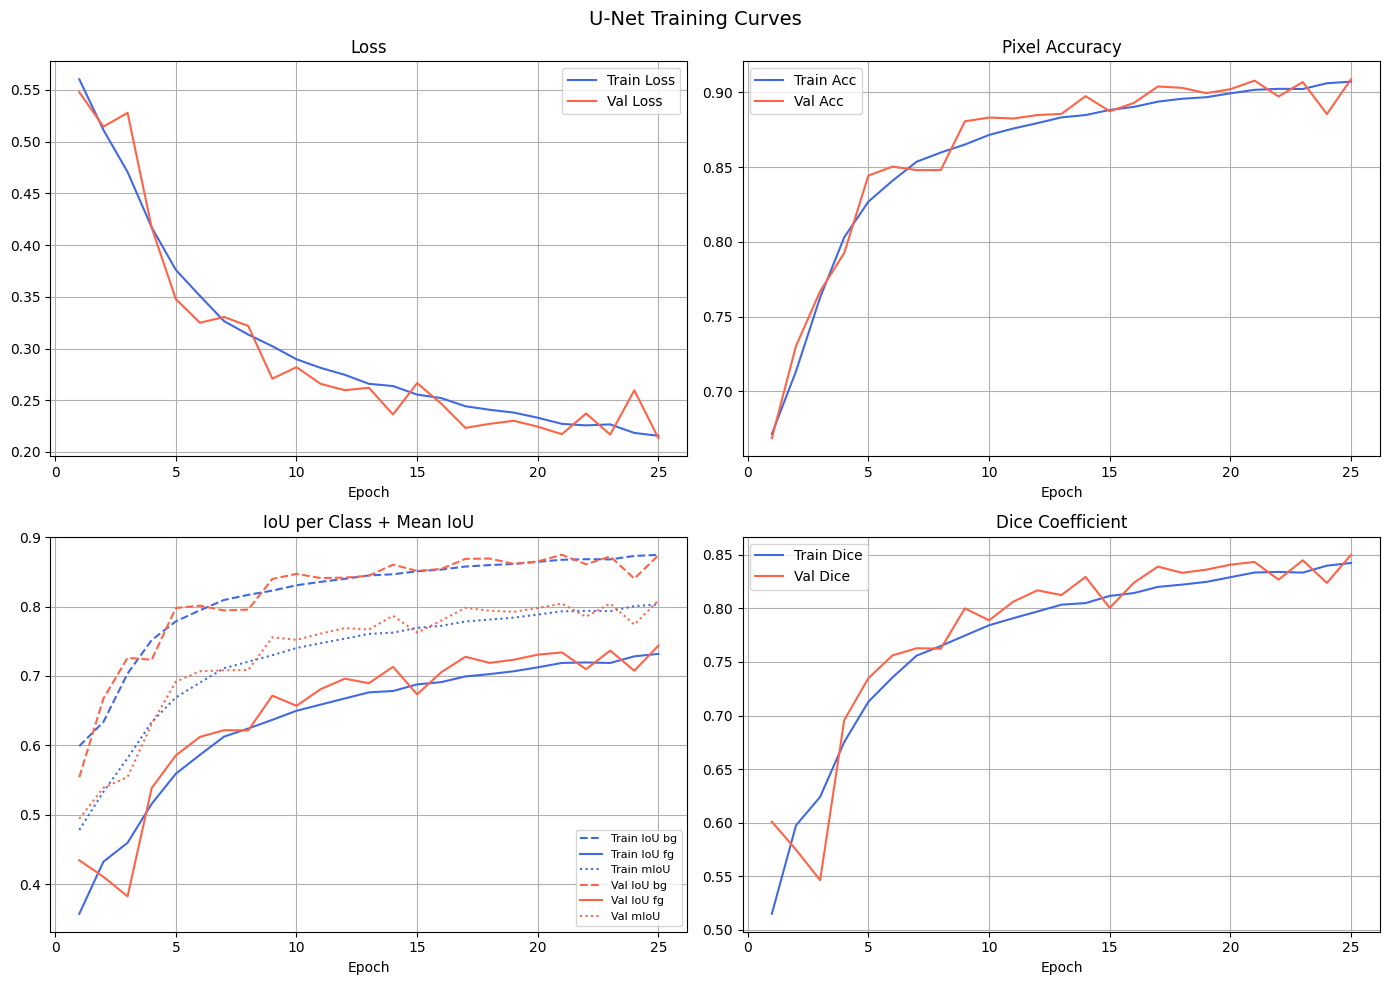

Saved training curves to training_curves.png


In [54]:
model   = load_best_model(model, save_path="best_model.pth", device=device)
results = evaluate_model(model, test_loader, device=device)
print_results(results)
visualize_predictions(model, test_loader, device=device, num_samples=6)
plot_history(history)